In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, parameters
from msfm.fiducial_pipeline import FiducialPipeline
from msfm.grid_pipeline import GridPipeline

from deep_lss.models.delta_model import DeltaLossModel
from deep_lss.nets import resnet
from deep_lss.utils import utils, distribute, delta_loss

23-06-06 05:30:44    scales.py INF   Setting up healpy to run on 128 CPUs 


### configs

In [2]:
msfm_conf = files.load_config()
dlss_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/delta_loss_debug/dlss_config.yaml")
# dlss_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/lensing_only/dlss_config.yaml")
net_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/resnet_debug.yaml")
# net_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/resnet_vanilla.yaml")

# dlss 
params = dlss_conf["dset"]["training"]["params"]
n_params = len(params)

# msfm
data_vec_pix, _, _, _ = files.load_pixel_file(msfm_conf)
n_side = msfm_conf["analysis"]["n_side"]

n_z_bins = 0
if dlss_conf["dset"]["general"]["with_lensing"]:
    n_z_bins += len(msfm_conf["survey"]["metacal"]["z_bins"])
if dlss_conf["dset"]["general"]["with_clustering"]:
    n_z_bins += len(msfm_conf["survey"]["maglim"]["z_bins"])

23-06-06 05:30:45     utils.py INF   Loaded the config 
23-06-06 05:30:45     utils.py INF   Loaded the config 
23-06-06 05:30:45     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


In [3]:
local_batch_size = 2
global_batch_size = 4 * local_batch_size
checkpoint_dir="/pscratch/sd/a/athomsen/run_files/v3/debug/2023-06-01_04-33-01_resnet_vanilla/checkpoint"
# checkpoint_dir="/pscratch/sd/a/athomsen/run_files/v3/2023-06-02_05-32-45_resnet_vanilla/checkpoint"
perts = parameters.get_fiducial_perturbations(params)

### training set

In [4]:
fiducial_pipeline = FiducialPipeline(
    conf=msfm_conf,
    with_lensing=True,
    with_clustering=False,
    apply_norm=True,
    params=params,
)
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v3/fiducial/DESy3_fiducial_001.tfrecord"

23-06-06 05:30:45     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-06-06 05:30:45     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


2023-06-06 05:30:46.787904: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-06 05:30:48.555951: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38218 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2023-06-06 05:30:48.557677: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38218 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2023-06-06 05:30:48.559236: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/devi

### delta loss

In [5]:
general_loss_function = lambda dv_batch, batch_size, strategy: delta_loss.delta_loss(
    predictions=dv_batch,
    n_params=n_params,
    n_same=batch_size,
    off_sets=perts,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=strategy,
)

# distributed

### model

In [6]:
strategy = distribute.get_strategy(True)

with strategy.scope():
    # load the layers
    network = resnet.ResNetLayers(
        output_shape=n_params, **net_conf["model"]["kwargs"]
    ).get_layers()

    # build the model
    dist_model = DeltaLossModel(
        network=network,
        n_side=n_side,
        indices=data_vec_pix,
        n_neighbors=net_conf["model"]["n_neighbors"],
        max_checkpoints=net_conf["model"]["max_checkpoints"],
        input_shape=(None, len(data_vec_pix), n_z_bins),
        checkpoint_dir=checkpoint_dir,
        summary_dir=None,
        restore_checkpoint=True,
    )
    
dist_model.setup_delta_loss_step(
    n_params,
    local_batch_size,
    perts,
    n_channels=n_z_bins,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=strategy,
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
23-06-06 05:30:49 distribute.p INF   Training is distributed, using MirroredStrategy 
23-06-06 05:30:49 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Model: "healpy_gcnn_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 healpy_pseudo_conv (HealpyP  (None, 116224, 32)       544       
 seudoConv)                                                      
                                                                 
 healpy_pseudo_conv_1 (Healp  (None, 29056, 64)

### training set

In [7]:
def dataset_fn(input_context):
    # dset = fiducial_pipeline.get_multi_noise_dset(
    dset = fiducial_pipeline.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=local_batch_size,
        n_readers=1,
        n_prefetch=None,
        file_name_shuffle_buffer=1,
        examples_shuffle_buffer=None,
        is_eval=True,
        # distribution
        input_context=input_context,
    )
    return dset

dist_dset = strategy.distribute_datasets_from_function(dataset_fn)
dist_iter = iter(dist_dset)
dist_dv_batch, dist_index_batch = next(dist_iter)

23-06-06 05:30:50 fiducial_pip WAR   Evaluation mode is activated, the random seed is fixed and the dataset is not repeated 
23-06-06 05:30:50 fiducial_pip INF   Sharding the dataset according to the input_context 


/global/common/software/des/athomsen/dlss/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py:2210: UserWarning: The `deterministic` argument has no effect unless the `num_parallel_calls` argument is specified.
  warnings.warn("The `deterministic` argument has no effect unless the "


23-06-06 05:30:51 tfrecords.py WAR   Tracing parse_inverse_fiducial 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
23-06-06 05:30:52 fiducial_pip INF   Batching into 2 elements locally 
23-06-06 05:30:52 fiducial_pip WAR   Tracing _augmentations 
23-06-06 05:30:52 fiducial_pip INF   Running on the data_

### delta loss

In [8]:
dist_loss_function = lambda dv_batch: general_loss_function(dv_batch, local_batch_size, strategy)

### predict

In [9]:
dist_pred = strategy.run(dist_model, args=(dist_dv_batch,))
dist_loss = strategy.run(dist_loss_function, args=(dist_pred,))

2023-06-06 05:30:54.389132: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-06 05:30:54.907331: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-06-06 05:30:55.587349: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-06 05:30:56.598207: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-06 05:30:57.561777: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901


INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localho

2023-06-06 05:30:57.978223: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x351a15b0
2023-06-06 05:30:58.051467: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x329df9d0
2023-06-06 05:30:58.102119: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x34f1a4e0
2023-06-06 05:30:58.151881: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x34eec9a0


INFO:tensorflow:batch_all_reduce: 1 all-reduces with algorithm = nccl, num_packs = 1
loss 0 37.8815231
loss 1 37.8815231
loss 2 37.8815231
loss 3 37.8815231


# local

### model

In [10]:
network = resnet.ResNetLayers(
    output_shape=n_params, **net_conf["model"]["kwargs"]
).get_layers()

# build the model
local_model = DeltaLossModel(
    network=network,
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=net_conf["model"]["n_neighbors"],
    max_checkpoints=net_conf["model"]["max_checkpoints"],
    input_shape=(None, len(data_vec_pix), n_z_bins),
    checkpoint_dir=checkpoint_dir,
    summary_dir=None,
    restore_checkpoint=True,
)

local_model.setup_delta_loss_step(
    n_params,
    global_batch_size,
    perts,
    n_channels=n_z_bins,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=None,
)

23-06-06 05:30:59 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Model: "healpy_gcnn_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 healpy_pseudo_conv_5 (Healp  (None, 116224, 32)       544       
 yPseudoConv)                                                    
                                                                 
 healpy_pseudo_conv_6 (Healp  (None, 29056, 64)        8256      
 yPseudoConv)                                                    
                                                                 
 healpy_pseudo_conv_7 (Healp  (None, 7264, 128)        32896     
 yPseudoConv)                                                    
                                                

### training set

In [11]:
local_dset = fiducial_pipeline.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=global_batch_size,
        n_readers=1,
        n_prefetch=None,
        file_name_shuffle_buffer=1,
        examples_shuffle_buffer=None,
        is_eval=True,
)

local_iter = iter(local_dset)
local_dv_batch, local_index_batch = next(local_iter)

23-06-06 05:31:00 fiducial_pip WAR   Evaluation mode is activated, the random seed is fixed and the dataset is not repeated 
23-06-06 05:31:00 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-06-06 05:31:00 fiducial_pip INF   Batching into 8 elements locally 
23-06-06 05:31:00 fiducial_pip WAR   Tracing _augmentations 
23-06-06 05:31:00 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'kg_delta_Om_m', 'kg_delta_Om_p', 'kg_delta_s8_m', 'kg_delta_s8_p', 'sn']) 
23-06-06 05:31:00 fiducial_pip WAR   Tracing _lensing_augmentations 
23-06-06 05:31:00 fiducial_pip INF   Successfully generated the fiducial training set with element_spec (TensorSpec(shape=(None, 464896, 4), dtype=tf.float32, name=None), (TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))) for i_noise = 0 


### delta loss

In [12]:
local_loss_function = lambda dv_batch: general_loss_function(dv_batch, global_batch_size, None)

### predict

In [13]:
local_pred = local_model(local_dv_batch)
local_loss = local_loss_function(local_pred)

cov 0 [[[2.14546581e-05 7.32900207e-06]
  [7.32900207e-06 1.54140471e-05]]]
loss 0 39.6924858


# comparison

In [41]:
print(dist_loss)
print(local_loss)

PerReplica:{
  0: tf.Tensor(37.84891, shape=(), dtype=float32),
  1: tf.Tensor(37.84891, shape=(), dtype=float32),
  2: tf.Tensor(37.84891, shape=(), dtype=float32),
  3: tf.Tensor(37.84891, shape=(), dtype=float32)
}
tf.Tensor(39.10837, shape=(), dtype=float32)


In [42]:
print(dist_pred)
print(local_pred)

PerReplica:{
  0: tf.Tensor(
[[0.6996201  0.10816404]
 [0.7156283  0.11547562]
 [0.69954205 0.10691918]
 [0.71527743 0.11429293]
 [0.69974864 0.10939422]
 [0.7156317  0.11739293]
 [0.6993146  0.10681241]
 [0.7153643  0.11467629]
 [0.69959944 0.10925197]
 [0.7157886  0.11646923]], shape=(10, 2), dtype=float32),
  1: tf.Tensor(
[[0.7128108  0.10956077]
 [0.70854855 0.11825058]
 [0.7127538  0.10813799]
 [0.7078404  0.11597522]
 [0.71243674 0.11087573]
 [0.7078867  0.11920884]
 [0.7125988  0.10816694]
 [0.7085134  0.11701057]
 [0.712881   0.1106218 ]
 [0.7084196  0.11917713]], shape=(10, 2), dtype=float32),
  2: tf.Tensor(
[[0.7102808  0.11085185]
 [0.7091814  0.10897264]
 [0.7107419  0.11025309]
 [0.70887387 0.10679729]
 [0.71031636 0.11207571]
 [0.7086774  0.11060118]
 [0.710605   0.10985182]
 [0.70872116 0.10799596]
 [0.71037316 0.11224797]
 [0.7090676  0.10998434]], shape=(10, 2), dtype=float32),
  3: tf.Tensor(
[[0.71205914 0.11677841]
 [0.709422   0.11469128]
 [0.71100634 0.11549715]

In [16]:
local_dv_batch.shape

TensorShape([40, 464896, 4])

In [17]:
# identical batch
assert np.all(local_index_batch[0] == strategy.gather(dist_index_batch[0], axis=0))

# doesn't work because the ordering is different
# assert np.all(local_dv_batch == strategy.gather(dist_dv_batch, axis=0))
print(local_dv_batch[-1,1000:1010,0])
print(strategy.gather(dist_dv_batch, axis=0)[-1,1000:1010,0])

INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
tf.Tensor(
[ 0.6749027   1.742829    0.45120633  1.8013209   1.3298533   0.3127592
  1.9587305   1.4990143  -0.8549133  -1.610823  ], shape=(10,), dtype=float32)
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
tf.Tensor(
[ 0.674936    1.7428972   0.45124397  1.8013631   1.3299601   0.31290185
  1.9587717   1.4990939  -0.8546571  -1.6103846 ], shape=(10,), dtype=float32)


In [18]:
dist_pred = strategy.run(dist_model, args=(dist_dv_batch,))
print(dist_pred)

PerReplica:{
  0: tf.Tensor(
[[0.6996201  0.10816404]
 [0.7156283  0.11547562]
 [0.69954205 0.10691918]
 [0.71527743 0.11429293]
 [0.69974864 0.10939422]
 [0.7156317  0.11739293]
 [0.6993146  0.10681241]
 [0.7153643  0.11467629]
 [0.69959944 0.10925197]
 [0.7157886  0.11646923]], shape=(10, 2), dtype=float32),
  1: tf.Tensor(
[[0.7128108  0.10956077]
 [0.70854855 0.11825058]
 [0.7127538  0.10813799]
 [0.7078404  0.11597522]
 [0.71243674 0.11087573]
 [0.7078867  0.11920884]
 [0.7125988  0.10816694]
 [0.7085134  0.11701057]
 [0.712881   0.1106218 ]
 [0.7084196  0.11917713]], shape=(10, 2), dtype=float32),
  2: tf.Tensor(
[[0.7102808  0.11085185]
 [0.7091814  0.10897264]
 [0.7107419  0.11025309]
 [0.70887387 0.10679729]
 [0.71031636 0.11207571]
 [0.7086774  0.11060118]
 [0.710605   0.10985182]
 [0.70872116 0.10799596]
 [0.71037316 0.11224797]
 [0.7090676  0.10998434]], shape=(10, 2), dtype=float32),
  3: tf.Tensor(
[[0.71205914 0.11677841]
 [0.709422   0.11469128]
 [0.71100634 0.11549715]

In [19]:
local_pred = local_model(local_dv_batch)
print(local_pred)

tf.Tensor(
[[0.6997777  0.10806146]
 [0.71561    0.11530121]
 [0.71258634 0.10948288]
 [0.7081488  0.11843693]
 [0.7104088  0.11050414]
 [0.709041   0.10880812]
 [0.71167296 0.11634134]
 [0.7094517  0.11413527]
 [0.69989485 0.10693276]
 [0.715336   0.11403763]
 [0.71302885 0.10815851]
 [0.7075302  0.11603381]
 [0.7109371  0.10983002]
 [0.70910734 0.10638118]
 [0.71064293 0.11516544]
 [0.70860076 0.11276382]
 [0.70007575 0.1091558 ]
 [0.715666   0.11732388]
 [0.7124271  0.11115841]
 [0.70740366 0.11951342]
 [0.7104093  0.11186026]
 [0.70877326 0.11014479]
 [0.71130437 0.11777503]
 [0.70969707 0.11526445]
 [0.6996056  0.10658359]
 [0.7155753  0.11456285]
 [0.7123698  0.10814629]
 [0.70833534 0.1170354 ]
 [0.7107396  0.10964767]
 [0.7087629  0.10775854]
 [0.7115148  0.11542558]
 [0.7102316  0.11307882]
 [0.69987386 0.10898467]
 [0.71584    0.11648628]
 [0.71291673 0.11051684]
 [0.70832944 0.11932708]
 [0.71046376 0.11199076]
 [0.70917857 0.10977059]
 [0.71109957 0.11779028]
 [0.7085042  0

In [20]:
dist_model.delta_train_step(dist_dv_batch)

23-06-06 05:31:02 delta_model. WAR   Tracing distributed delta_train_step 
23-06-06 05:31:02 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-06 05:31:04 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-06 05:31:04 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-06 05:31:05 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', 

In [21]:
local_model.delta_train_step(local_dv_batch)

23-06-06 05:31:23 delta_model. WAR   Tracing delta_train_step 
23-06-06 05:31:23 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-06 05:31:24 delta_model. WAR   Tracing delta_train_step 
23-06-06 05:31:24 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
cov 0 [[[2.13373842e-05 7.417088e-06]
  [7.417088e-06 1.52637604e-05]]]
loss 0 39.5156403
glob_norm 0 1167.43225
gradients 0 [6.45355394e-05 6.17657424e-05 0.00026199178 ... -5.96693717e-05 -3.39421558e-06 -0.000219925569]


In [22]:
140327.422/646.063965

217.20360459973955

### delta loss

In [23]:
dist_loss = strategy.run(dist_loss_function, args=(dist_pred,))

cov 0 [[[2.19933172e-05 7.99410918e-06]
  [7.99410918e-06 1.52468137e-05]]]
cov 1 [[[2.19933172e-05 7.99410918e-06]
  [7.99410918e-06 1.52468137e-05]]]
cov 2 [[[2.19933172e-05 7.99410918e-06]
  [7.99410918e-06 1.52468137e-05]]]
cov 3 [[[2.19933172e-05 7.99410918e-06]
  [7.99410918e-06 1.52468137e-05]]]
loss 0 37.8489113
loss 1 37.8489113
loss 2 37.8489113
loss 3 37.8489113


In [24]:
local_loss = local_loss_function(local_pred)

cov 0 [[[2.12784162e-05 7.28815212e-06]
  [7.28815212e-06 1.5257634e-05]]]
loss 0 39.1083717


In [25]:
dist_loss

PerReplica:{
  0: <tf.Tensor: shape=(), dtype=float32, numpy=37.84891>,
  1: <tf.Tensor: shape=(), dtype=float32, numpy=37.84891>,
  2: <tf.Tensor: shape=(), dtype=float32, numpy=37.84891>,
  3: <tf.Tensor: shape=(), dtype=float32, numpy=37.84891>
}

In [26]:
local_loss

<tf.Tensor: shape=(), dtype=float32, numpy=39.10837>

In [27]:
print(strategy.gather(dist_index_batch[0], axis=0))
print(local_index_batch[0])

tf.Tensor([ 92  97 572 569 792 729 599 468], shape=(8,), dtype=int64)
tf.Tensor([ 92  97 572 569 792 729 599 468], shape=(8,), dtype=int64)


In [28]:
# tf.split(dist_pred, 2*n_params+1,axis=0)

In [29]:
# dist_pred

In [30]:
# temp = strategy.gather(dist_pred, axis=0)

In [31]:
# temp

In [32]:
# tf.split(temp, 2*n_params+1, axis=0)

In [33]:
dist_pred

PerReplica:{
  0: <tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[0.6996201 , 0.10816404],
       [0.7156283 , 0.11547562],
       [0.69954205, 0.10691918],
       [0.71527743, 0.11429293],
       [0.69974864, 0.10939422],
       [0.7156317 , 0.11739293],
       [0.6993146 , 0.10681241],
       [0.7153643 , 0.11467629],
       [0.69959944, 0.10925197],
       [0.7157886 , 0.11646923]], dtype=float32)>,
  1: <tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[0.7128108 , 0.10956077],
       [0.70854855, 0.11825058],
       [0.7127538 , 0.10813799],
       [0.7078404 , 0.11597522],
       [0.71243674, 0.11087573],
       [0.7078867 , 0.11920884],
       [0.7125988 , 0.10816694],
       [0.7085134 , 0.11701057],
       [0.712881  , 0.1106218 ],
       [0.7084196 , 0.11917713]], dtype=float32)>,
  2: <tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[0.7102808 , 0.11085185],
       [0.7091814 , 0.10897264],
       [0.7107419 , 0.11025309],
       [0.70887387, 0.10679729

In [34]:
local_pred

<tf.Tensor: shape=(40, 2), dtype=float32, numpy=
array([[0.6997777 , 0.10806146],
       [0.71561   , 0.11530121],
       [0.71258634, 0.10948288],
       [0.7081488 , 0.11843693],
       [0.7104088 , 0.11050414],
       [0.709041  , 0.10880812],
       [0.71167296, 0.11634134],
       [0.7094517 , 0.11413527],
       [0.69989485, 0.10693276],
       [0.715336  , 0.11403763],
       [0.71302885, 0.10815851],
       [0.7075302 , 0.11603381],
       [0.7109371 , 0.10983002],
       [0.70910734, 0.10638118],
       [0.71064293, 0.11516544],
       [0.70860076, 0.11276382],
       [0.70007575, 0.1091558 ],
       [0.715666  , 0.11732388],
       [0.7124271 , 0.11115841],
       [0.70740366, 0.11951342],
       [0.7104093 , 0.11186026],
       [0.70877326, 0.11014479],
       [0.71130437, 0.11777503],
       [0.70969707, 0.11526445],
       [0.6996056 , 0.10658359],
       [0.7155753 , 0.11456285],
       [0.7123698 , 0.10814629],
       [0.70833534, 0.1170354 ],
       [0.7107396 , 0.10964

In [35]:
print(strategy.gather(dist_pred, axis=0))
print(local_pred)

tf.Tensor(
[[0.6996201  0.10816404]
 [0.7156283  0.11547562]
 [0.69954205 0.10691918]
 [0.71527743 0.11429293]
 [0.69974864 0.10939422]
 [0.7156317  0.11739293]
 [0.6993146  0.10681241]
 [0.7153643  0.11467629]
 [0.69959944 0.10925197]
 [0.7157886  0.11646923]
 [0.7128108  0.10956077]
 [0.70854855 0.11825058]
 [0.7127538  0.10813799]
 [0.7078404  0.11597522]
 [0.71243674 0.11087573]
 [0.7078867  0.11920884]
 [0.7125988  0.10816694]
 [0.7085134  0.11701057]
 [0.712881   0.1106218 ]
 [0.7084196  0.11917713]
 [0.7102808  0.11085185]
 [0.7091814  0.10897264]
 [0.7107419  0.11025309]
 [0.70887387 0.10679729]
 [0.71031636 0.11207571]
 [0.7086774  0.11060118]
 [0.710605   0.10985182]
 [0.70872116 0.10799596]
 [0.71037316 0.11224797]
 [0.7090676  0.10998434]
 [0.71205914 0.11677841]
 [0.709422   0.11469128]
 [0.71100634 0.11549715]
 [0.7085215  0.11288445]
 [0.7116776  0.1180115 ]
 [0.7100152  0.11586728]
 [0.7117818  0.11578443]
 [0.71026874 0.11368576]
 [0.7114062  0.11802679]
 [0.7087059  0

In [36]:
# print(strategy.gather(dist_loss, axis=0))
print(strategy.reduce(tf.distribute.ReduceOp.MEAN, dist_loss, axis=None))
print(local_loss)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
tf.Tensor(37.84891, shape=(), dtype=float32)
tf.Tensor(39.10837, shape=(), dtype=float32)


In [37]:
gathered_dist_pred = strategy.gather(dist_pred, axis=0)

(array([ 3.,  3.,  4.,  5., 18., 30.,  5.,  6.,  3.,  3.]),
 array([-0.0130443 , -0.01048756, -0.00793083, -0.00537409, -0.00281736,
        -0.00026062,  0.00229611,  0.00485285,  0.00740958,  0.00996632,
         0.01252306]),
 <BarContainer object of 10 artists>)

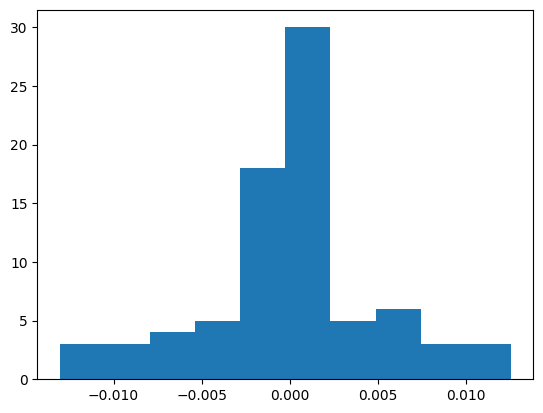

In [38]:
plt.hist((gathered_dist_pred - local_pred).numpy().ravel())

In [39]:
local_pred

<tf.Tensor: shape=(40, 2), dtype=float32, numpy=
array([[0.6997777 , 0.10806146],
       [0.71561   , 0.11530121],
       [0.71258634, 0.10948288],
       [0.7081488 , 0.11843693],
       [0.7104088 , 0.11050414],
       [0.709041  , 0.10880812],
       [0.71167296, 0.11634134],
       [0.7094517 , 0.11413527],
       [0.69989485, 0.10693276],
       [0.715336  , 0.11403763],
       [0.71302885, 0.10815851],
       [0.7075302 , 0.11603381],
       [0.7109371 , 0.10983002],
       [0.70910734, 0.10638118],
       [0.71064293, 0.11516544],
       [0.70860076, 0.11276382],
       [0.70007575, 0.1091558 ],
       [0.715666  , 0.11732388],
       [0.7124271 , 0.11115841],
       [0.70740366, 0.11951342],
       [0.7104093 , 0.11186026],
       [0.70877326, 0.11014479],
       [0.71130437, 0.11777503],
       [0.70969707, 0.11526445],
       [0.6996056 , 0.10658359],
       [0.7155753 , 0.11456285],
       [0.7123698 , 0.10814629],
       [0.70833534, 0.1170354 ],
       [0.7107396 , 0.10964

In [40]:
local_loss_function(gathered_dist_pred)

cov 0 [[[7.24386919e-05 3.49088914e-05]
  [3.49088914e-05 1.81131581e-05]]]
loss 0 30.8461037


<tf.Tensor: shape=(), dtype=float32, numpy=30.846104>